In [55]:
import pandas as pd
import numpy as np 

1.1 --- LOAD THE DATASET ---

In [56]:
df = pd.read_csv('data.csv')

1. Exploratory Data Analysis (EDA) - Dataset Inspection

In [57]:
head = df.head()
shape = df.shape  
columns = df.columns  
info = df.info() 
missing_total = df.isnull().sum().sum()
target_counts = df['Class'].value_counts()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB


In [58]:

# Print all info after EDA
print("===== Head of Dataset =====")
print(head)
print("\n===== Dataset Shape =====")
print(shape)
print("\n===== Columns =====")
print(columns)
print("\n===== Total Missing Values =====")
print(missing_total)
print("\n===== Target Distribution =====")
print(target_counts)

===== Head of Dataset =====
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C 

Step 1b: EDA - Visualizations

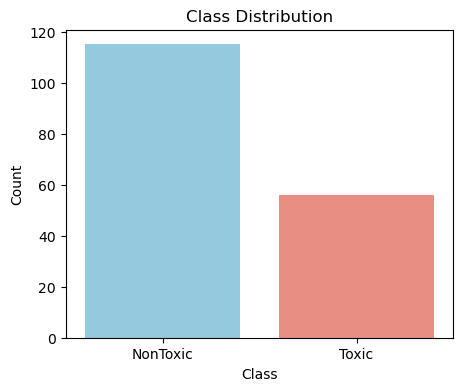

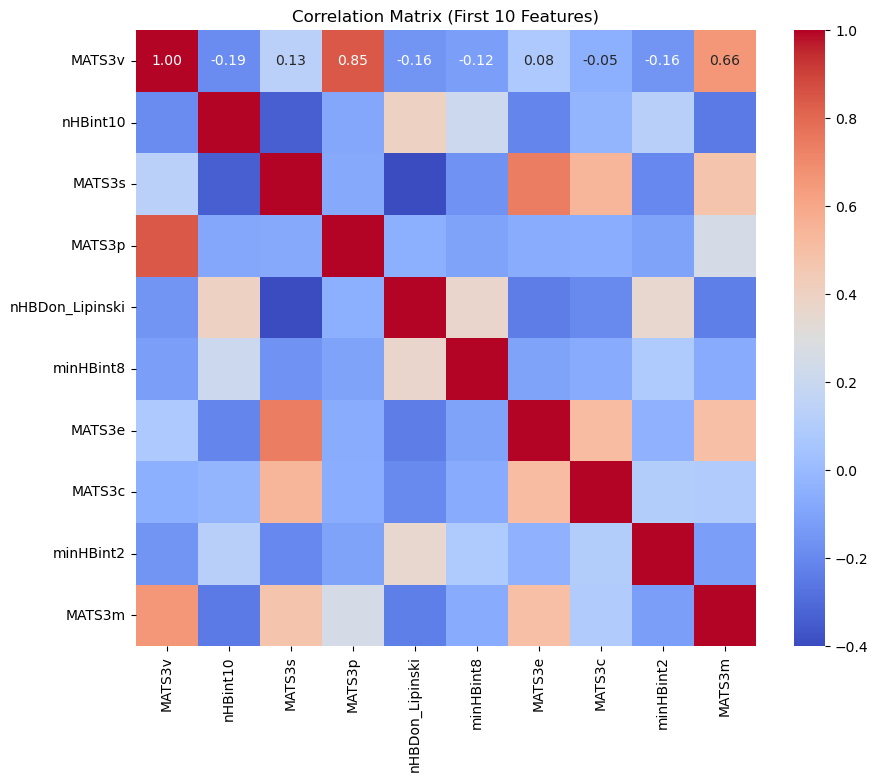

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Visualize target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df, palette=['skyblue','salmon'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 2️⃣ Correlation matrix (first 10 features for clarity)
corr_matrix = df.drop(columns='Class').iloc[:, :10].corr()  # select first 10 features
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (First 10 Features)")
plt.show()



 ----------- DATA PREPROCESSING --------------

In [60]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler



In [61]:
# preprocessing reusable func.
# returns: X (features), y (encoded target), preprocessors dict
def preprocess_data(df, target_col='Class'):
    
    df_clean = df.copy()
    
    # Handle infinite values
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    # Separate numeric and categorical columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    
    # Remove target from categorical list if present
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)
    
    # Initialize imputers as None (will only be created if needed)
    imputer_num = None
    imputer_cat = None
    
    # Impute numeric columns with median
    if numeric_cols:
        imputer_num = SimpleImputer(strategy='median')
        df_clean[numeric_cols] = imputer_num.fit_transform(df_clean[numeric_cols])
    
    # Impute categorical columns with most frequent
    if categorical_cols:
        imputer_cat = SimpleImputer(strategy='most_frequent')
        df_clean[categorical_cols] = imputer_cat.fit_transform(df_clean[categorical_cols])
    
    # Remove duplicate rows
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    
    # Encode categorical features
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        encoders[col] = le
    
    # Encode target
    le_target = LabelEncoder()
    df_clean[target_col] = le_target.fit_transform(df_clean[target_col])
    encoders[target_col] = le_target
    
    # Remove constant numeric features
    constant_cols = [col for col in numeric_cols if df_clean[col].std() == 0]
    if constant_cols:
        df_clean.drop(columns=constant_cols, inplace=True)
        numeric_cols = [c for c in numeric_cols if c not in constant_cols]
    
    # Scale numeric features
    scaler = StandardScaler()
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    
    # Separate features and target
    X = df_clean.drop(target_col, axis=1)
    y = df_clean[target_col]
    
    preprocessors = {
        'numeric_imputer': imputer_num,
        'categorical_imputer': imputer_cat,
        'encoders': encoders,
        'scaler': scaler,
        'numeric_cols': numeric_cols,
        'categorical_cols': categorical_cols
    }
    
    return X, y, preprocessors

# Now use the function
X, y, preprocessors = preprocess_data(df, target_col='Class')

print("Features shape:", X.shape)
print("Target distribution:", pd.Series(y).value_counts())

Features shape: (171, 1203)
Target distribution: Class
0    115
1     56
Name: count, dtype: int64
